<a href="https://colab.research.google.com/github/Apolinar1o/IcMachinaLearning/blob/main/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# Upload do arquivo
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("Nenhum arquivo foi selecionado.")

nome_arquivo = list(uploaded.keys())[0]
caminho = f"/content/{nome_arquivo}"

dataset = pd.read_csv(caminho)

Saving exame_diabes.csv to exame_diabes (9).csv


In [ ]:
#mostrar tabela
dataset.head(10)

,idade,peso,altura,resultado,genero_F,genero_M
0,46,83,165,98,0,1
1,23,83,164,82,1,0
2,39,71,154,93,0,1
3,26,103,165,95,1,0
4,27,55,176,100,0,1
5,64,93,190,117,0,1
6,21,70,182,90,1,0
7,60,101,179,84,1,0
8,63,83,189,92,1,0
9,65,78,175,121,1,0


In [ ]:
#tira a redundacia do id e genero
dataset.drop(columns=['id_paciente'], inplace=True)
dataset.get_dummies(dataset, columns=['genero'])
dataset.dataset.astype(int)

In [ ]:
#adicionando o imc
dataset["imc"] = dataset["peso"] / ((dataset["altura"]/100) ** 2)

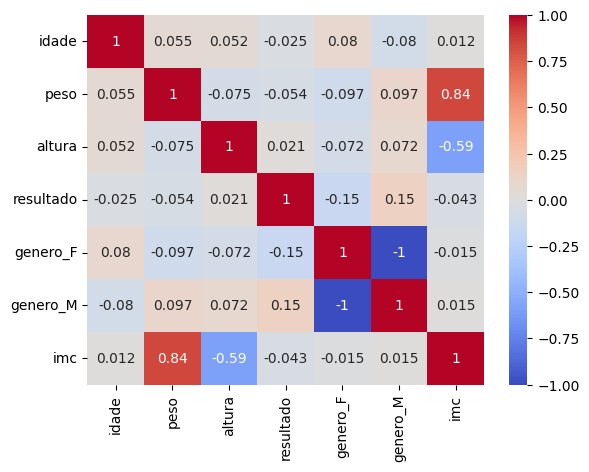

In [ ]:
#Graficos da matriz de correlação
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
from numpy import random
#Divisão dos dados
x = dataset.drop(columns=['resultado'])
y = dataset['resultado']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.5, random_state=51)



In [ ]:
#TReino do modelo
model = linear_model.LogisticRegression().fit(x_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#previsao com o modelo
y_pred = model.predict(x_test)
y_pred

array([ 98, 111, 101,  90, 112, 101, 112, 101, 115,  90, 101, 101, 118,
       105, 122, 111,  98, 101, 111,  90, 112, 118, 129,  90,  98,  90,
        94, 101, 111,  98,  98, 125, 111,  95, 111, 130, 104,  95,  90,
       117,  95, 112, 115, 112, 122,  90, 105, 104,  95,  90])

In [ ]:
# Avaliação das métricas
print(f"Acurácia (modelo de classificação): {model.score(x_test, y_test):.4f}")
print("\n--- Métricas de Regressão (mais apropriadas para valores contínuos) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"R-squared (R2): {r2_score(y_test, y_pred):.4f}")

Acurácia (modelo de classificação): 0.0000

--- Métricas de Regressão (mais apropriadas para valores contínuos) ---
Mean Absolute Error (MAE): 17.0600
Mean Squared Error (MSE): 396.3000
R-squared (R2): -0.8302
